Loaded Raw data-EPM_Preinduction-Trial     1.xlsx → EPM_FP0
Loaded Raw data-EPM_Preinduction-Trial     2.xlsx → EPM_FP1
Loaded Raw data-EPM_Preinduction-Trial     3.xlsx → EPM_FP2
Loaded Raw data-EPM_Preinduction-Trial     4.xlsx → EPM_FP3
Loaded Raw data-EPM_Preinduction-Trial     5.xlsx → EPM_FP5


ValueError: x and y must have same first dimension, but have shapes (3,) and (61393,)

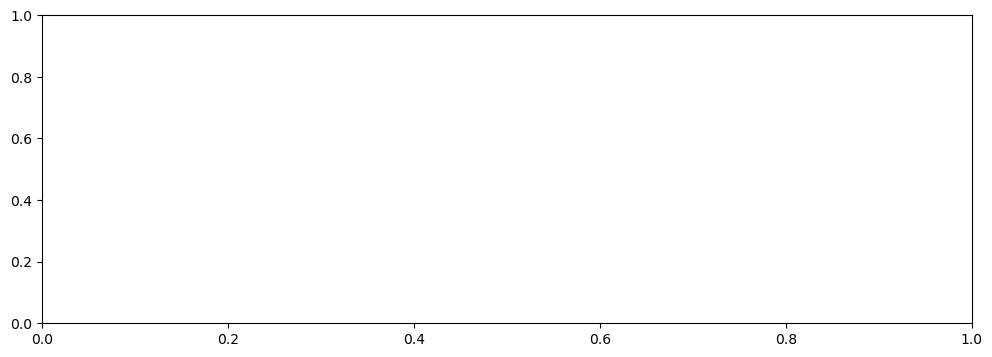

In [1]:
# ==========================================================
#  AUTOMATED PIPELINE: Load all FP data and plot each trace
# ==========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Step 1: Define your main directory
# ----------------------------------------------------------
# Use '.' if the notebook is located in the main directory
main_dir = Path(".").resolve()

# ----------------------------------------------------------
# Step 2: Helper functions
# ----------------------------------------------------------
def find_fp_id_in_export(export_path: Path) -> str:
    """Return the FP folder id (e.g. 'EPM_FP0') from the trial export file."""
    if export_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(export_path, header=None)
    else:
        df = pd.read_csv(export_path, header=None)
    first_col = df.iloc[:, 0].astype(str).str.strip()
    matches = df[first_col.str.lower() == "fp file"]
    if matches.empty:
        raise ValueError(f"'FP file' not found in {export_path.name}")
    row_idx = matches.index[0]
    fp_id = str(df.iloc[row_idx, 1]).strip()
    if not fp_id or fp_id.lower() == "nan":
        raise ValueError(f"Empty FP id in {export_path.name}")
    return fp_id


def load_fp_folder(main_dir: Path, fp_id: str) -> dict:
    """Load FP csv and timestamp csv from the corresponding FP folder."""
    fp_folder = main_dir / fp_id
    if not fp_folder.is_dir():
        raise FileNotFoundError(f"FP folder not found: {fp_folder}")
    # FP CSV
    exact = list(fp_folder.glob(f"{fp_id}.csv"))
    if exact:
        fp_csv = exact[0]
    else:
        cands = sorted(p for p in fp_folder.glob("*.csv") if fp_id.lower() in p.name.lower())
        if not cands:
            raise FileNotFoundError(f"No FP csv for {fp_id}")
        fp_csv = cands[0]
    # Timestamp CSV
    ts_cands = sorted(fp_folder.glob("timestamp*.csv"))
    if not ts_cands:
        ts_cands = sorted(p for p in fp_folder.glob("*.csv") if "time" in p.name.lower())
    if not ts_cands:
        raise FileNotFoundError(f"No timestamp csv found in {fp_folder}")
    ts_csv = ts_cands[0]
    fp_df = pd.read_csv(fp_csv)
    ts_df = pd.read_csv(ts_csv)
    return dict(fp_folder=fp_folder, fp_csv_path=fp_csv, timestamp_csv_path=ts_csv,
                fp_df=fp_df, timestamp_df=ts_df)


def load_all_trials(main_dir: Path, export_folder_name="Export files", trial_glob="*"):
    """Load all trial exports and their matching FP data."""
    export_dir = main_dir / export_folder_name
    trials = sorted([p for p in export_dir.glob(trial_glob)
                     if p.suffix.lower() in {".xlsx", ".xls", ".csv"}])
    results = []
    for t in trials:
        try:
            fp_id = find_fp_id_in_export(t)
            bundle = load_fp_folder(main_dir, fp_id)
            bundle.update(dict(trial_path=t, fp_id=fp_id))
            results.append(bundle)
            print(f"Loaded {t.name} → {fp_id}")
        except Exception as e:
            print(f"[WARN] {t.name}: {e}")
    return results


def _detect_time_vector(fp_df, timestamp_df):
    """Auto-detect time vector from FP or timestamp data."""
    time_candidates = ["time","t","seconds","sec","timestamp","frame_time","frame"]
    cols_lower = {c.lower(): c for c in fp_df.columns}
    for c in time_candidates:
        if c in cols_lower:
            t = pd.to_numeric(fp_df[cols_lower[c]], errors="coerce")
            if t.notna().sum() >= len(fp_df)*0.8:
                return t.values
    if timestamp_df is not None and not timestamp_df.empty:
        for c in timestamp_df.columns:
            if pd.api.types.is_numeric_dtype(timestamp_df[c]):
                t = pd.to_numeric(timestamp_df[c], errors="coerce")
                t = t - np.nanmin(t)
                return t.values
    return np.arange(len(fp_df), dtype=float)


def plot_fp_traces(data_bundles, main_dir, save=True, show=False):
    """Plot FP traces for each mouse and save as PNGs."""
    main_dir = Path(main_dir)
    fig_dir = main_dir / "Figures"
    if save:
        fig_dir.mkdir(exist_ok=True)
    for b in data_bundles:
        fp_id = b["fp_id"]
        fp_df = b["fp_df"]
        timestamp_df = b.get("timestamp_df")
        t = _detect_time_vector(fp_df, timestamp_df)
        drop_like = {"time","t","seconds","sec","timestamp","frame_time","frame","index"}
        numeric_cols = [c for c in fp_df.columns if pd.api.types.is_numeric_dtype(fp_df[c]) and c.lower() not in drop_like]
        if not numeric_cols:
            print(f"[WARN] {fp_id}: no numeric columns to plot")
            continue
        plt.figure(figsize=(12,4))
        for c in numeric_cols:
            plt.plot(t[:len(fp_df[c])], fp_df[c], label=c, lw=1)
        plt.title(f"{fp_id} — FP traces")
        plt.xlabel("Time")
        plt.ylabel("Signal")
        plt.legend()
        plt.tight_layout()
        if save:
            out = fig_dir / f"{fp_id}_traces.png"
            plt.savefig(out, dpi=200)
            print(f"Saved {out}")
        if show:
            plt.show()
        else:
            plt.close()

# ----------------------------------------------------------
# Step 3: Run everything
# ----------------------------------------------------------
data_bundles = load_all_trials(main_dir)
plot_fp_traces(data_bundles, main_dir, save=True, show=False)

print("\n✅ All FP traces plotted and saved in the 'Figures' folder.")


In [ ]:
# ==========================================================
#  AUTOMATED PIPELINE with TIMESTAMP TRIMMING
#  - Loads all trial exports in "Export files"
#  - Finds FP folder (e.g., EPM_FP0) from "FP file" row
#  - Loads FP csv + timestamp csv
#  - Trims FP data to [start, stop] from timestamp file
#  - Plots all numeric FP channels vs time and saves PNGs
# ==========================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

main_dir = Path(".").resolve()  # use '.' if this notebook lives in your main directory

# -------------------------
# Helpers
# -------------------------
def find_fp_id_in_export(export_path: Path) -> str:
    """Return the FP folder id (e.g. 'EPM_FP0') from the trial export file."""
    if export_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(export_path, header=None)
    else:
        df = pd.read_csv(export_path, header=None)

    first_col = df.iloc[:, 0].astype(str).str.strip()
    matches = df[first_col.str.lower() == "fp file"]
    if matches.empty:
        raise ValueError(f"'FP file' not found in {export_path.name}")

    row_idx = matches.index[0]
    fp_id = str(df.iloc[row_idx, 1]).strip()
    if not fp_id or fp_id.lower() == "nan":
        raise ValueError(f"Empty FP id in {export_path.name}")
    return fp_id


def load_fp_folder(main_dir: Path, fp_id: str) -> dict:
    """Load FP csv and timestamp csv from the corresponding FP folder."""
    fp_folder = main_dir / fp_id
    if not fp_folder.is_dir():
        raise FileNotFoundError(f"FP folder not found: {fp_folder}")

    # FP CSV (prefer exact match; fall back to any csv containing the id)
    exact = list(fp_folder.glob(f"{fp_id}.csv"))
    if exact:
        fp_csv = exact[0]
    else:
        cands = sorted(p for p in fp_folder.glob("*.csv") if fp_id.lower() in p.name.lower())
        if not cands:
            raise FileNotFoundError(f"No FP csv for {fp_id}")
        fp_csv = cands[0]

    # Timestamp CSV (prefer 'timestamp*.csv'; fall back to any file with 'time' in name)
    ts_cands = sorted(fp_folder.glob("timestamp*.csv"))
    if not ts_cands:
        ts_cands = sorted(p for p in fp_folder.glob("*.csv") if "time" in p.name.lower())
    if not ts_cands:
        raise FileNotFoundError(f"No timestamp csv found in {fp_folder}")
    ts_csv = ts_cands[0]

    fp_df = pd.read_csv(fp_csv)
    ts_df = pd.read_csv(ts_csv)
    return dict(fp_folder=fp_folder, fp_csv_path=fp_csv, timestamp_csv_path=ts_csv,
                fp_df=fp_df, timestamp_df=ts_df)


def load_all_trials(main_dir: Path, export_folder_name="Export files", trial_glob="*"):
    """Load all trial exports and their matching FP data."""
    export_dir = main_dir / export_folder_name
    trials = sorted([p for p in export_dir.glob(trial_glob)
                     if p.suffix.lower() in {".xlsx", ".xls", ".csv"}])
    if not trials:
        print(f"[WARN] No trial files found in: {export_dir}")
    results = []
    for t in trials:
        try:
            fp_id = find_fp_id_in_export(t)
            bundle = load_fp_folder(main_dir, fp_id)
            bundle.update(dict(trial_path=t, fp_id=fp_id))
            results.append(bundle)
            print(f"Loaded {t.name} → {fp_id}")
        except Exception as e:
            print(f"[WARN] {t.name}: {e}")
    return results


def _detect_time_vector(fp_df: pd.DataFrame, timestamp_df: pd.DataFrame | None):
    """
    Build a time vector for FP data.
    Priority: an explicit time-like column in fp_df; else first numeric column in timestamp_df;
    else fall back to sample index (0..N-1).
    """
    time_candidates = ["time","t","seconds","sec","timestamp","frame_time","frame"]
    cols_lower = {c.lower(): c for c in fp_df.columns}
    for c in time_candidates:
        if c in cols_lower:
            t = pd.to_numeric(fp_df[cols_lower[c]], errors="coerce")
            if t.notna().sum() >= len(fp_df) * 0.8:
                return t.values

    if timestamp_df is not None and not timestamp_df.empty:
        for c in timestamp_df.columns:
            if pd.api.types.is_numeric_dtype(timestamp_df[c]):
                t = pd.to_numeric(timestamp_df[c], errors="coerce")
                t = t - np.nanmin(t)
                return t.values

    return np.arange(len(fp_df), dtype=float)


def _extract_start_stop_from_timestamp(timestamp_df: pd.DataFrame) -> tuple | None:
    """
    Robustly infer a (start, stop) window from the timestamp file.
    - Collect all numeric values across numeric columns,
    - Use the min as start and max as stop.
    Returns (start, stop) or None if not inferable.
    """
    if timestamp_df is None or timestamp_df.empty:
        return None

    numeric_vals = []
    for c in timestamp_df.columns:
        if pd.api.types.is_numeric_dtype(timestamp_df[c]):
            vals = pd.to_numeric(timestamp_df[c], errors="coerce").to_numpy()
            numeric_vals.append(vals)

    if not numeric_vals:
        return None

    all_vals = np.concatenate(numeric_vals)
    all_vals = all_vals[np.isfinite(all_vals)]
    if all_vals.size < 2:
        return None

    start = np.nanmin(all_vals)
    stop  = np.nanmax(all_vals)
    if stop <= start:
        return None
    return float(start), float(stop)


def _trim_to_span(fp_df: pd.DataFrame, t: np.ndarray, span: tuple[float, float]):
    """
    Trim FP data to the [start, stop] span.
    If times don't match exactly, snap to the FP time *just before* the requested time.
    Returns (fp_df_trimmed, t_trimmed, idx_start, idx_stop).
    """
    start, stop = span
    # ensure t is 1-D float array
    t = np.asarray(t, dtype=float).ravel()
    if t.size != len(fp_df):
        # if mismatch (e.g., a separate sampling length), reindex to the shorter length
        n = min(t.size, len(fp_df))
        t = t[:n]
        fp_df = fp_df.iloc[:n, :].reset_index(drop=True)

    # searchsorted with 'right' then minus 1 gives the greatest index with t[idx] <= query
    idx_start = max(0, np.searchsorted(t, start, side="right") - 1)
    idx_stop  = np.searchsorted(t, stop, side="right") - 1
    idx_stop  = max(idx_stop, idx_start)               # guard against inversion
    idx_stop  = min(idx_stop, len(t) - 1)             # in-bounds

    fp_df_trim = fp_df.iloc[idx_start:idx_stop + 1, :].reset_index(drop=True)
    t_trim = t[idx_start:idx_stop + 1] - t[idx_start]  # shift to start at 0
    return fp_df_trim, t_trim, idx_start, idx_stop


def plot_fp_traces(data_bundles, main_dir, save=True, show=False):
    """Plot FP traces (after trimming by timestamp span) for each mouse and save PNGs."""
    main_dir = Path(main_dir)
    fig_dir = main_dir / "Figures"
    if save:
        fig_dir.mkdir(exist_ok=True)

    for b in data_bundles:
        fp_id = b["fp_id"]
        fp_df = b["fp_df"].copy()
        ts_df = b.get("timestamp_df", None)

        # Build full time vector first
        t_full = _detect_time_vector(fp_df, ts_df)
        # Extract span from timestamp file and trim
        span = _extract_start_stop_from_timestamp(ts_df)
        if span is not None:
            fp_df, t, i0, i1 = _trim_to_span(fp_df, t_full, span)
            print(f"{fp_id}: trimmed to [{span[0]:.4f}, {span[1]:.4f}] "
                  f"→ indices [{i0}, {i1}] (N={len(t)})")
        else:
            t = t_full
            print(f"{fp_id}: no valid start/stop span found — plotting full trace (N={len(t)})")

        # choose numeric columns to plot (exclude obvious time-like columns)
        drop_like = {"time","t","seconds","sec","timestamp","frame_time","frame","index"}
        numeric_cols = [c for c in fp_df.columns
                        if pd.api.types.is_numeric_dtype(fp_df[c]) and c.lower() not in drop_like]
        if not numeric_cols:
            print(f"[WARN] {fp_id}: no numeric FP channels to plot")
            continue

        plt.figure(figsize=(12, 4.2))
        for c in numeric_cols:
            y = pd.to_numeric(fp_df[c], errors="coerce").to_numpy()
            plt.plot(t[:len(y)], y, label=c, lw=1)

        plt.title(f"{fp_id} — FP traces (trimmed by timestamp)" if span is not None else f"{fp_id} — FP traces")
        plt.xlabel("Time (s)")
        plt.ylabel("Signal")
        plt.legend(loc="best", ncols=min(4, len(numeric_cols)))
        plt.tight_layout()

        if save:
            out = fig_dir / f"{fp_id}_traces.png"
            plt.savefig(out, dpi=200)
            print(f"Saved {out}")
        if show:
            plt.show()
        else:
            plt.close()


# -------------------------
# Run everything
# -------------------------
data_bundles = load_all_trials(main_dir)
plot_fp_traces(data_bundles, main_dir, save=True, show=False)

print("\n✅ Done. Figures saved in ./Figures")


Loaded Raw data-EPM_Preinduction-Trial     1.xlsx → EPM_FP0
Loaded Raw data-EPM_Preinduction-Trial     2.xlsx → EPM_FP1
Loaded Raw data-EPM_Preinduction-Trial     3.xlsx → EPM_FP2
Loaded Raw data-EPM_Preinduction-Trial     4.xlsx → EPM_FP3
Loaded Raw data-EPM_Preinduction-Trial     5.xlsx → EPM_FP5
[WARN] Statistics-EPM_Preinduction.xlsx: 'FP file' not found in Statistics-EPM_Preinduction.xlsx
[WARN] ~$Raw data-EPM_Preinduction-Trial     1.xlsx: Excel file format cannot be determined, you must specify an engine manually.
EPM_FP0: trimmed to [0.0000, 54302300.4583] → indices [1, 2] (N=2)
Saved /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Preinduction/Figures/EPM_FP0_traces.png
EPM_FP1: trimmed to [0.0000, 57383076.5312] → indices [1, 1] (N=1)
Saved /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Preinduction/Figures/EPM_FP1_traces.png
EPM_FP2: trimmed to [0.0000, 59141646.9842] → indices [1, 1] (N=1)
Saved /Users/annastuckert/Documents/GitHub/FP_behaviou

In [ ]:
# ==========================================================
# Automated OFT/EPM combiner:
# - For each "Raw data-*.xlsx" in ./Export files/
# - Read FP id from "FP file" row
# - Load FP csv + timestamp csv from the FP folder
# - Trim FP to [video_start, video_stop] using DigitalIOState
# - Load EthoVision (header row 39) and build ethogram
# - Plot LED1, LED2, and ethogram; save PNG per trial
# ==========================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# User parameters
# -------------------------------------------------
main_dir = Path(".").resolve()
export_dir = main_dir / "Export files"

# Behaviors to try to pull from EthoVision
behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage"
]

# Video and FP frame rates (used only if EthoVision lacks a time column)
video_fps = 50.0         # EthoVision video rate
fp_fps = 50.0            # overall FP rate (25 Hz per LED if interleaved 2-color)

# Where to save figures
fig_dir = main_dir / "Figures"
fig_dir.mkdir(exist_ok=True, parents=True)

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def _read_export_and_get_fp_id(xl_path: Path) -> str:
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()
    match = df[key_col == "fp file"]
    if match.empty:
        raise ValueError(f"'FP file' row not found in {xl_path.name}")
    row_idx = match.index[0]
    fp_id = str(df.iloc[row_idx, 1]).strip()
    if not fp_id or fp_id.lower() == "nan":
        raise ValueError(f"Empty FP id in {xl_path.name}")
    return fp_id

def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str) -> tuple[Path, Path]:
    # Prefer exact <fp_id>.csv for FP
    fp_candidates = list(fp_folder.glob(f"{fp_id}.csv"))
    if not fp_candidates:
        # fallback: any csv that contains the id
        fp_candidates = [p for p in fp_folder.glob("*.csv") if fp_id.lower() in p.name.lower()]
    if not fp_candidates:
        raise FileNotFoundError(f"No FP csv in {fp_folder} for id {fp_id}")
    fp_csv = sorted(fp_candidates)[0]

    # Timestamp candidates
    ts_candidates = list(fp_folder.glob("timestamp*.csv"))
    if not ts_candidates:
        ts_candidates = [p for p in fp_folder.glob("*.csv") if "time" in p.name.lower()]
    if not ts_candidates:
        raise FileNotFoundError(f"No timestamp csv in {fp_folder}")
    ts_csv = sorted(ts_candidates)[0]
    return fp_csv, ts_csv

def _coerce_bool_col(series: pd.Series) -> pd.Series:
    # Handles True/False, 1/0, "True"/"False", "true"/"false"
    s = series.copy()
    if s.dtype == bool:
        return s
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(int).astype(bool)
    # text
    low = s.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])

def _get_video_window(ts: pd.DataFrame) -> tuple[float, float]:
    # Expect two events: DigitalIOState True = start, False = stop
    if "DigitalIOState" not in ts.columns or "SystemTimestamp" not in ts.columns:
        # try to guess closest names
        candidates_state = [c for c in ts.columns if "digital" in c.lower() or "state" in c.lower()]
        candidates_time  = [c for c in ts.columns if "time" in c.lower()]
        if not candidates_state or not candidates_time:
            raise ValueError("Could not find DigitalIOState/SystemTimestamp columns in timestamp file")
        state_col = candidates_state[0]
        time_col  = candidates_time[0]
    else:
        state_col = "DigitalIOState"
        time_col  = "SystemTimestamp"

    state = _coerce_bool_col(ts[state_col])
    t = pd.to_numeric(ts[time_col], errors="coerce")

    if state.sum() == 0 or (~state).sum() == 0:
        raise ValueError("Timestamp file must contain at least one True and one False in DigitalIOState")

    video_start = float(t[state].iloc[0])
    video_stop  = float(t[~state].iloc[0])
    if not np.isfinite(video_start) or not np.isfinite(video_stop):
        raise ValueError("Non-finite start/stop in timestamp")
    if video_stop <= video_start:
        # sometimes order is reversed or multiple pulses exist; take min/max
        video_start = float(np.nanmin(t[state]))
        video_stop  = float(np.nanmax(t[~state]))
    return video_start, video_stop

def _build_time_vector_from_fp(fp_df: pd.DataFrame) -> np.ndarray:
    # Prefer SystemTimestamp if present, else construct from sample index and fp_fps
    if "SystemTimestamp" in fp_df.columns:
        tt = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce").to_numpy()
        if np.isfinite(tt).sum() >= len(tt) * 0.8:
            return tt
    # fallback to a synthetic time vector
    n = len(fp_df)
    return np.arange(n, dtype=float) / fp_fps

def _snap_down_index(t: np.ndarray, target: float) -> int:
    # index of the last t <= target; if all t > target, return 0
    idx = max(0, np.searchsorted(t, target, side="right") - 1)
    return idx

def _trim_fp_to_window(fp_df: pd.DataFrame, start: float, stop: float) -> pd.DataFrame:
    # Build time vector and snap to window
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n, :].reset_index(drop=True)

    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    i1 = max(i1, i0)
    fp_trim = fp_df.iloc[i0:i1+1, :].copy()
    # Make a plotting time referenced to video start
    fp_trim["Time_video"] = tt[i0:i1+1] - tt[i0]
    return fp_trim

def _load_ethovision_sheet(eth_path: Path, behaviors_of_interest: list[str], video_fps: float) -> tuple[pd.DataFrame, list[str]]:
    # EthoVision header row is 39 -> header=38
    eth = pd.read_excel(eth_path, header=38)
    eth = eth.dropna(axis=1, how="all")

    # Detect time column
    time_col = next((c for c in eth.columns if "time" in str(c).lower()), None)
    if time_col is None:
        eth["Time_s"] = np.arange(len(eth)) / video_fps
    else:
        eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

    beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
    return eth[["Time_s"] + beh_cols].copy(), beh_cols

def _ethogram_segments(eth: pd.DataFrame, beh_cols: list[str]) -> pd.DataFrame:
    segments = []
    for beh in beh_cols:
        mask = (eth[beh] == 1)
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"].values
        ends = eth.loc[diff == -1, "Time_s"].values
        if mask.iloc[0]:
            starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
        if mask.iloc[-1]:
            ends = np.append(ends, eth["Time_s"].iloc[-1])
        for s, e in zip(starts, ends):
            segments.append({"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e), "Duration_s": float(e - s)})
    if not segments:
        return pd.DataFrame(columns=["Behavior", "Start_time_s", "End_time_s", "Duration_s"])
    return pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

def _plot_trial(fp_trim: pd.DataFrame, eth_timeline: pd.DataFrame, beh_cols: list[str], out_png: Path, title_prefix: str):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1]})

    # LED 1 and LED 2 only
    if "LedState" not in fp_trim.columns:
        raise ValueError("FP csv must contain 'LedState' column with values 1 and 2")
    if "G0" not in fp_trim.columns:
        # if the channel is named differently, try the first numeric column not in the excluded set
        exclude = {"SystemTimestamp", "LedState", "Time_video", "Time_s", "Timestamp"}
        num_cols = [c for c in fp_trim.columns if pd.api.types.is_numeric_dtype(fp_trim[c]) and c not in exclude]
        if not num_cols:
            raise ValueError("Could not find numeric FP channel like 'G0'")
        chan = num_cols[0]
    else:
        chan = "G0"

    # LED 1 (isosbestic)
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8)
    axes[0].set_ylabel(f"{chan} (LED 1 - Isosbestic)")
    axes[0].set_title(f"{title_prefix}: LED 1 (isosbestic)")
    axes[0].grid(True)

    # LED 2 (GCaMP)
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8)
    axes[1].set_ylabel(f"{chan} (LED 2 - GCaMP)")
    axes[1].set_title(f"{title_prefix}: LED 2 (GCaMP)")
    axes[1].grid(True)

    # Ethogram
    if eth_timeline is not None and not eth_timeline.empty:
        behaviors = beh_cols
        if not behaviors:
            behaviors = eth_timeline["Behavior"].unique().tolist()
        for i, beh in enumerate(behaviors):
            sub = eth_timeline[eth_timeline["Behavior"] == beh]
            for _, row in sub.iterrows():
                axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"], height=0.6)
        axes[2].set_yticks(range(len(behaviors)))
        axes[2].set_yticklabels(behaviors)
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Ethogram (Behavior Occurrence)")
        axes[2].invert_yaxis()

    # Shared x limits
    axes[-1].set_xlim(fp_trim["Time_video"].min(), fp_trim["Time_video"].max())
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

# -------------------------------------------------
# Main loop
# -------------------------------------------------
trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
if not trial_files:
    print(f"[WARN] No 'Raw data-*.xlsx' files found in {export_dir}")

for eth_path in trial_files:
    try:
        # FP id from EthoVision export file
        fp_id = _read_export_and_get_fp_id(eth_path)

        # Resolve FP folder and files
        fp_folder = main_dir / fp_id
        if not fp_folder.is_dir():
            raise FileNotFoundError(f"FP folder not found: {fp_folder}")
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

        # Load FP and filter LED 1 & 2
        fp = pd.read_csv(fp_csv)
        if "LedState" not in fp.columns:
            raise ValueError(f"'LedState' column missing in {fp_csv.name}")
        fp = fp[fp["LedState"].isin([1, 2])].copy()

        # Load timestamp and derive window
        ts = pd.read_csv(ts_csv)
        video_start, video_stop = _get_video_window(ts)

        # Trim FP to the window using snap-down logic
        fp_trim = _trim_fp_to_window(fp, start=video_start, stop=video_stop)

        # Load EthoVision and build ethogram
        eth, beh_cols = _load_ethovision_sheet(eth_path, behaviors_of_interest, video_fps)
        timeline = _ethogram_segments(eth, beh_cols)

        # Plot and save
        trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
        out_png = fig_dir / f"{fp_id}__{trial_stub}.png"
        _plot_trial(fp_trim, timeline, beh_cols, out_png, title_prefix=f"{fp_id} — {trial_stub}")
        print(f"OK: {eth_path.name} → {fp_id}  |  Figure: {out_png.name}")

    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")


OK: Raw data-EPM_Preinduction-Trial     1.xlsx → EPM_FP0  |  Figure: EPM_FP0__EPM_Preinduction-Trial_____1.png
OK: Raw data-EPM_Preinduction-Trial     2.xlsx → EPM_FP1  |  Figure: EPM_FP1__EPM_Preinduction-Trial_____2.png
OK: Raw data-EPM_Preinduction-Trial     3.xlsx → EPM_FP2  |  Figure: EPM_FP2__EPM_Preinduction-Trial_____3.png
OK: Raw data-EPM_Preinduction-Trial     4.xlsx → EPM_FP3  |  Figure: EPM_FP3__EPM_Preinduction-Trial_____4.png
OK: Raw data-EPM_Preinduction-Trial     5.xlsx → EPM_FP5  |  Figure: EPM_FP5__EPM_Preinduction-Trial_____5.png
